# 03 — Modeling (Regression First)

This notebook starts with **regression** to predict `number_of_streams`, then moves to:
- classification (`is_popular`)
- clustering (track segments)


In [1]:
# Imports
from pathlib import Path
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.metrics import silhouette_score


In [2]:
# Load engineered data
DATA_DIR = Path('..') / 'src'
MODELS_DIR = Path('..') / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_DIR / 'feature_engineered_album.csv')
print('Data shape:', df.shape)
df.head(3)


Data shape: (309, 16)


,release_year,album_type,album_name,track_name,bpm,number_of_streams,total_time_played,total_time_played_h,average_ms_played,average_ms_played_min,song_length_min,avg_percent_song_played,song_age_years,average_played_sec,bpm_x_completion,is_popular
0,2018,Mini Album,I am NOT,3rd Eye,140,32,7554514,2:05:55,236078.56,3:56,4:03,97,8,236.07856,13580,0
1,2018,Mini Album,I am NOT,Awaken,164,33,6399256,1:46:39,193916.85,3:13,3:13,100,8,193.91685,16400,0
2,2018,Mini Album,I am NOT,District 9,90,151,32233152,8:57:13,213464.58,3:33,3:33,100,8,213.46458,9000,1


In [3]:
# Shared feature setup
num_features = [
    c for c in [
        'release_year', 'bpm', 'average_ms_played', 'avg_percent_song_played',
        'song_age_years', 'average_played_sec', 'bpm_x_completion',
        'bpm_x_length', 'total_played_sec', 'avg_played_sec', 'play_count'
    ] if c in df.columns
]
cat_features = [c for c in ['album_type'] if c in df.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_features),
    ],
    remainder='drop'
)

print('Numeric features:', num_features)
print('Categorical features:', cat_features)


Numeric features: ['release_year', 'bpm', 'average_ms_played', 'avg_percent_song_played', 'song_age_years', 'average_played_sec', 'bpm_x_completion']
Categorical features: ['album_type']


## Regression Baselines
Target: `number_of_streams`

In [4]:
# Prepare regression data
reg_df = df.dropna(subset=['number_of_streams']).copy()
X_reg = reg_df[num_features + cat_features]
y_reg = reg_df['number_of_streams']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=300, random_state=42),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42),
    'ExtraTreesRegressor': ExtraTreesRegressor(n_estimators=300, random_state=42),
}

reg_results = []
reg_fitted = {}

for name, model in reg_models.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', model)])
    pipe.fit(Xr_train, yr_train)
    pred = pipe.predict(Xr_test)
    mae = mean_absolute_error(yr_test, pred)
    rmse = np.sqrt(mean_squared_error(yr_test, pred))
    r2 = r2_score(yr_test, pred)
    reg_results.append({'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    reg_fitted[name] = pipe

reg_results_df = pd.DataFrame(reg_results).sort_values('RMSE')
reg_results_df


,model,MAE,RMSE,R2
4,ExtraTreesRegressor,20.736452,31.276078,0.891251
3,GradientBoostingRegressor,29.056105,38.859711,0.832119
2,RandomForestRegressor,28.647957,41.516014,0.808383
0,LinearRegression,53.046782,66.722334,0.505069
1,Ridge,52.914753,66.834323,0.503406


In [5]:
# Save best regression model
best_reg_name = reg_results_df.iloc[0]['model']
best_reg_model = reg_fitted[best_reg_name]
reg_model_path = MODELS_DIR / 'best_regression_model.pkl'
joblib.dump(best_reg_model, reg_model_path)

print('Best regression model:', best_reg_name)
print('Saved to:', reg_model_path)


Best regression model: ExtraTreesRegressor
Saved to: ..\models\best_regression_model.pkl


## Classification Baselines
Target: `is_popular`

In [6]:
# Prepare classification data
clf_df = df.dropna(subset=['is_popular']).copy()
X_clf = clf_df[num_features + cat_features]
y_clf = clf_df['is_popular'].astype(int)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

clf_models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=300, random_state=42),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42),
}

clf_results = []
clf_fitted = {}

for name, model in clf_models.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', model)])
    pipe.fit(Xc_train, yc_train)
    pred = pipe.predict(Xc_test)
    acc = accuracy_score(yc_test, pred)
    f1 = f1_score(yc_test, pred)
    prec = precision_score(yc_test, pred)
    rec = recall_score(yc_test, pred)
    clf_results.append({'model': name, 'Accuracy': acc, 'F1': f1, 'Precision': prec, 'Recall': rec})
    clf_fitted[name] = pipe

clf_results_df = pd.DataFrame(clf_results).sort_values('F1', ascending=False)
clf_results_df


,model,Accuracy,F1,Precision,Recall
1,RandomForestClassifier,0.919355,0.827586,0.923077,0.750
2,GradientBoostingClassifier,0.903226,0.800000,0.857143,0.750
0,LogisticRegression,0.903226,0.769231,1.000000,0.625


## Clustering
Unsupervised clustering with engineered numeric features.

In [7]:
# KMeans clustering
cluster_features = [c for c in num_features if c in df.columns]
cluster_df = df[cluster_features].copy()

cluster_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_cluster = cluster_pipe.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_cluster)

df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

sil = silhouette_score(X_cluster, cluster_labels)
print('Silhouette score:', round(sil, 4))
print(df_clustered['cluster'].value_counts().sort_index())


Silhouette score: 0.2835
cluster
0    101
1     86
2    117
3      5
Name: count, dtype: int64


## Hyperparameter Tuning
Tune the strongest baseline models from regression and classification.

In [8]:
# Hyperparameter tuning for top models
from sklearn.model_selection import RandomizedSearchCV

# Regression tuning: ExtraTreesRegressor
tuned_reg_pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', ExtraTreesRegressor(random_state=42))
])

reg_param_dist = {
    'model__n_estimators': [200, 300, 500, 800],
    'model__max_depth': [None, 8, 12, 16, 24],
    'model__min_samples_split': [2, 4, 8],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None],
}

reg_search = RandomizedSearchCV(
    estimator=tuned_reg_pipe,
    param_distributions=reg_param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
)
reg_search.fit(Xr_train, yr_train)
reg_best = reg_search.best_estimator_
reg_pred_tuned = reg_best.predict(Xr_test)

reg_tuned_metrics = {
    'MAE': mean_absolute_error(yr_test, reg_pred_tuned),
    'RMSE': np.sqrt(mean_squared_error(yr_test, reg_pred_tuned)),
    'R2': r2_score(yr_test, reg_pred_tuned),
}

# Classification tuning: RandomForestClassifier
tuned_clf_pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

clf_param_dist = {
    'model__n_estimators': [200, 300, 500, 800],
    'model__max_depth': [None, 6, 10, 16, 24],
    'model__min_samples_split': [2, 4, 8],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None],
}

clf_search = RandomizedSearchCV(
    estimator=tuned_clf_pipe,
    param_distributions=clf_param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
)
clf_search.fit(Xc_train, yc_train)
clf_best = clf_search.best_estimator_
clf_pred_tuned = clf_best.predict(Xc_test)

clf_tuned_metrics = {
    'Accuracy': accuracy_score(yc_test, clf_pred_tuned),
    'F1': f1_score(yc_test, clf_pred_tuned),
    'Precision': precision_score(yc_test, clf_pred_tuned),
    'Recall': recall_score(yc_test, clf_pred_tuned),
}

print('Tuned Regression Metrics:', reg_tuned_metrics)
print('Tuned Classification Metrics:', clf_tuned_metrics)
print('Best regression params:', reg_search.best_params_)
print('Best classification params:', clf_search.best_params_)


Tuned Regression Metrics: {'MAE': 24.807704301075276, 'RMSE': np.float64(33.40301734189609), 'R2': 0.8759565755459536}
Tuned Classification Metrics: {'Accuracy': 0.9193548387096774, 'F1': 0.8275862068965517, 'Precision': 0.9230769230769231, 'Recall': 0.75}
Best regression params: {'model__n_estimators': 500, 'model__min_samples_split': 4, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best classification params: {'model__n_estimators': 500, 'model__min_samples_split': 4, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}


In [9]:
# Save tuned models
joblib.dump(reg_best, MODELS_DIR / 'tuned_regression_model.pkl')
joblib.dump(clf_best, MODELS_DIR / 'tuned_classification_model.pkl')
print('Saved tuned models to', MODELS_DIR)


Saved tuned models to ..\models


## Feature Importance & Interpretation

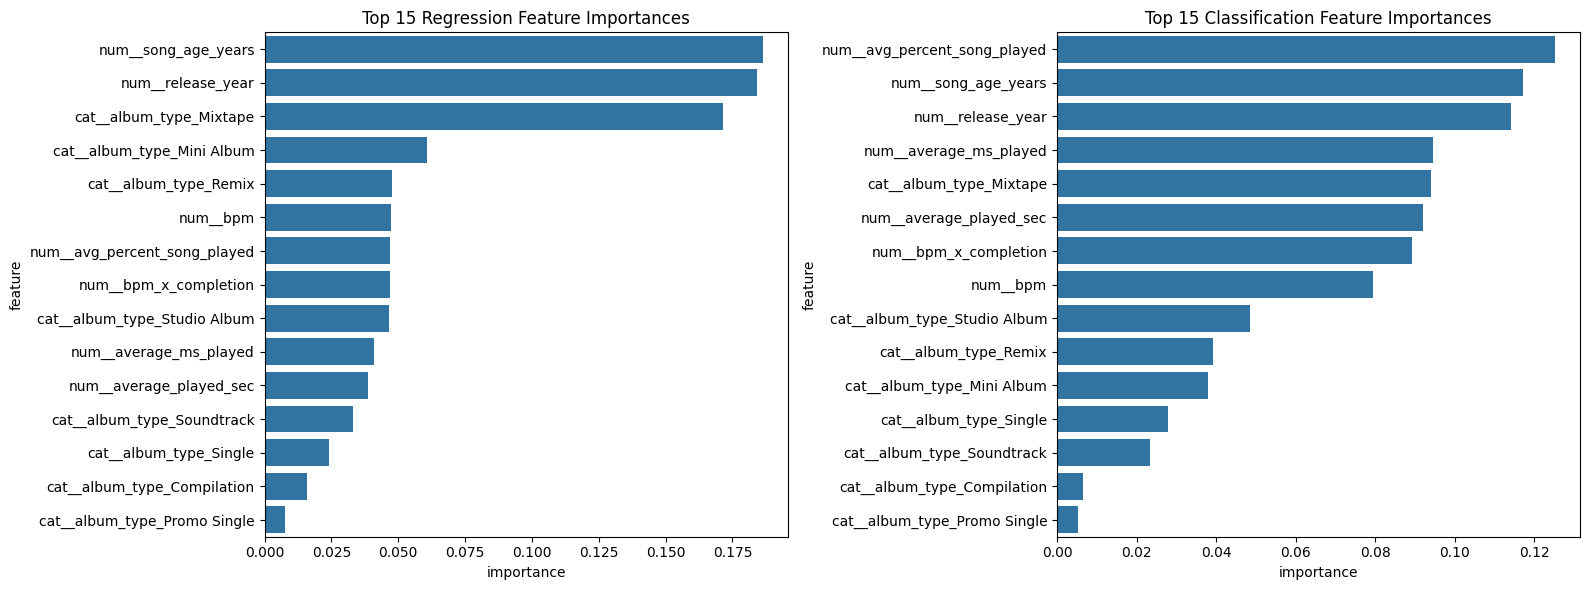

(                         feature  importance
 4            num__song_age_years    0.186264
 0              num__release_year    0.184349
 9        cat__album_type_Mixtape    0.171613
 8     cat__album_type_Mini Album    0.060935
 11         cat__album_type_Remix    0.047654
 1                       num__bpm    0.047375
 3   num__avg_percent_song_played    0.047039
 6          num__bpm_x_completion    0.046744
 15  cat__album_type_Studio Album    0.046529
 2         num__average_ms_played    0.040756
 5        num__average_played_sec    0.038590
 14    cat__album_type_Soundtrack    0.033262
 13        cat__album_type_Single    0.023930
 7    cat__album_type_Compilation    0.016040
 10  cat__album_type_Promo Single    0.007690,
                          feature  importance
 3   num__avg_percent_song_played    0.125295
 4            num__song_age_years    0.117171
 0              num__release_year    0.114097
 2         num__average_ms_played    0.094524
 9        cat__album_type_Mixtape

In [10]:
# Feature importance from tuned models
import matplotlib.pyplot as plt
import seaborn as sns

# Recover transformed feature names for interpretation
prep_fitted = reg_best.named_steps['prep']
feature_names = prep_fitted.get_feature_names_out()

reg_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': reg_best.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False).head(15)

clf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': clf_best.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=reg_importance, x='importance', y='feature', ax=axes[0])
axes[0].set_title('Top 15 Regression Feature Importances')

sns.barplot(data=clf_importance, x='importance', y='feature', ax=axes[1])
axes[1].set_title('Top 15 Classification Feature Importances')

plt.tight_layout()
plt.show()

reg_importance, clf_importance
